In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
 # =============================================================
# STEP 1 — CREATE DATASET
# We predict house price based on size and number of rooms
# =============================================================
 
np.random.seed(42)

n = 100  # number of samples
 
size  = np.random.uniform(500, 3500, n)          # sq ft
rooms = np.random.randint(1, 6, n).astype(float) # number of rooms
 
# True relationship (what we want the model to learn)
# price = 50*size + 8000*rooms + 20000 + noise
noise = np.random.normal(0, 15000, n)
price = 50 * size + 8000 * rooms + 20000 + noise
 
print("Dataset shape:", size.shape, rooms.shape, price.shape)
print("Price range: ${:.0f}  to  ${:.0f}".format(price.min(), price.max()))
 

Dataset shape: (100,) (100,) (100,)
Price range: $42800  to  $231945


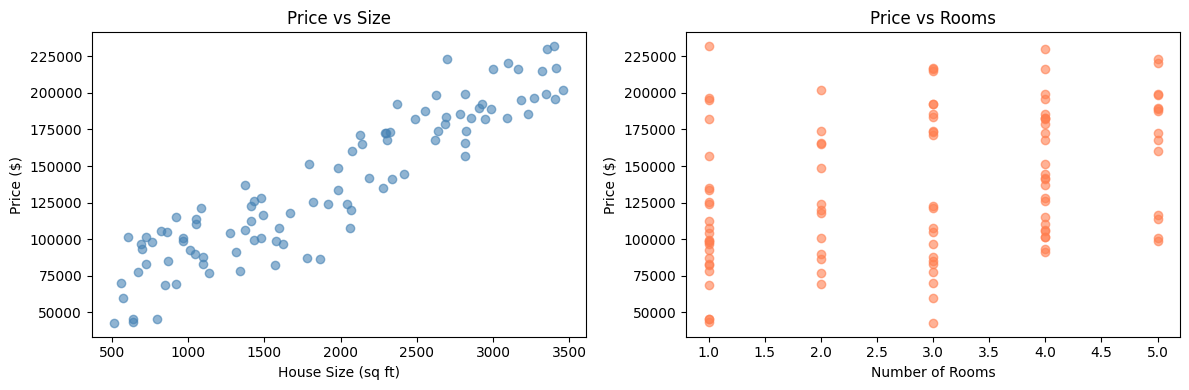

Plot saved.


In [6]:
# =============================================================
# STEP 2 — BASIC VISUALIZATION
# =============================================================
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].scatter(size, price, alpha=0.6, color='steelblue')
axes[0].set_xlabel("House Size (sq ft)")
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Price vs Size")
 
axes[1].scatter(rooms, price, alpha=0.6, color='coral')
axes[1].set_xlabel("Number of Rooms")
axes[1].set_ylabel("Price ($)")
axes[1].set_title("Price vs Rooms")
 
plt.tight_layout()
plt.show()
print("Plot saved.")

In [7]:
# =============================================================
# STEP 3 — TRAIN / TEST SPLIT  (80/20, done manually)
# =============================================================
 
indices   = np.arange(n)
np.random.shuffle(indices)
 
split     = int(0.8 * n)
train_idx = indices[:split]
test_idx  = indices[split:]
 
X_train = np.column_stack([size[train_idx],  rooms[train_idx]])
X_test  = np.column_stack([size[test_idx],   rooms[test_idx]])
y_train = price[train_idx]
y_test  = price[test_idx]
 
print(f"\nTrain samples: {len(train_idx)}, Test samples: {len(test_idx)}")
 


Train samples: 80, Test samples: 20


In [8]:
# =============================================================
# STEP 4 — FEATURE SCALING  (standardize: mean=0, std=1)
# We scale features so gradient descent converges faster
# =============================================================
 
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
 
X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test  - mean) / std   # use TRAIN mean/std on test too
 
print("\nFeature means (train):", mean)
print("Feature stds  (train):", std)


Feature means (train): [1891.67565593    2.8625    ]
Feature stds  (train): [892.70892046   1.39412831]


In [9]:
 
# =============================================================
# STEP 5 — ADD BIAS COLUMN (column of 1s)
# Our model: price = w0*1 + w1*size + w2*rooms
# The column of 1s lets w0 act as the intercept/bias
# =============================================================
 
ones        = np.ones((X_train_scaled.shape[0], 1))
X_train_b   = np.hstack([ones, X_train_scaled])   # shape (80, 3)
 
ones_test   = np.ones((X_test_scaled.shape[0], 1))
X_test_b    = np.hstack([ones_test, X_test_scaled])

In [10]:
# =============================================================
# STEP 6 — INITIALIZE PARAMETERS
# w = [w0, w1, w2]  — all start at zero
# =============================================================
 
w = np.zeros(X_train_b.shape[1])   # [0, 0, 0]
print("\nInitial weights:", w)


Initial weights: [0. 0. 0.]


In [12]:
# =============================================================
# STEP 7 — PREDICTION & ERROR (MSE LOSS)
#
# Prediction:  y_hat = X @ w        (matrix multiply)
# Error (MSE): L = (1/n) * sum( (y_hat - y)^2 )
# =============================================================
 
# Quick test before training
y_hat_init = X_train_b @ w
mse_init   = np.mean((y_hat_init - y_train) ** 2)
print(f"\nMSE before training: {mse_init}")


MSE before training: 21141909187.247997


In [13]:
# =============================================================
# STEP 8 — GRADIENT DESCENT
#
# Gradient of MSE w.r.t. w:
#   dL/dw = (2/n) * X^T @ (y_hat - y)
#
# Weight update:
#   w = w - learning_rate * dL/dw
# =============================================================
 
learning_rate = 0.01
epochs        = 500
loss_history  = []
 
for epoch in range(epochs):
 
    # --- forward pass: predict ---
    y_hat = X_train_b @ w
 
    # --- calculate error ---
    error = y_hat - y_train                          # shape (80,)
    mse   = np.mean(error ** 2)
    loss_history.append(mse)
 
    # --- calculate gradient ---
    gradient = (2 / len(y_train)) * (X_train_b.T @ error)  # shape (3,)
 
    # --- update weights ---
    w = w - learning_rate * gradient
 
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}  |  MSE: {mse:>15,.0f}  |  w: {w}")
 
print(f"\nFinal weights : {w}")
print(f"True  weights : [20000 (bias after scaling), ~scaled w1, ~scaled w2]")
 
 

Epoch    0  |  MSE:  21,141,909,187  |  w: [2728.47641972  933.71384981  363.60934353]
Epoch  100  |  MSE:     603,924,268  |  w: [118693.20376431  39185.08117848  11157.82633607]
Epoch  200  |  MSE:     250,088,845  |  w: [134072.39440421  44057.15660638  10873.16284934]
Epoch  300  |  MSE:     243,708,500  |  w: [136111.97583689  44755.93991949  10603.4568652 ]
Epoch  400  |  MSE:     243,587,088  |  w: [136382.4642207   44866.95269178  10532.57725657]

Final weights : [136418.22433706  44885.83898325  10517.43547866]
True  weights : [20000 (bias after scaling), ~scaled w1, ~scaled w2]


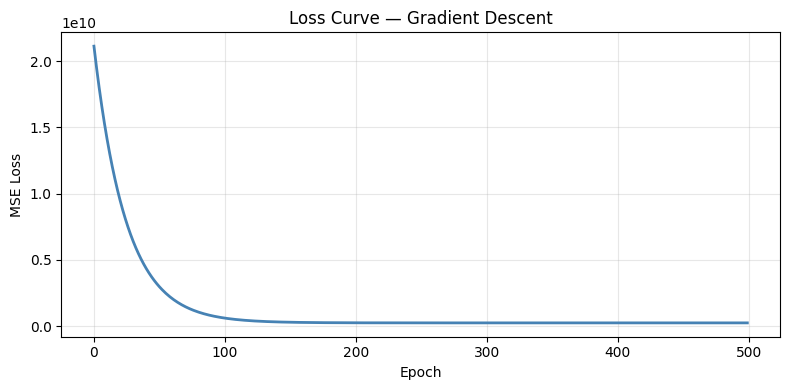

Loss curve saved.


In [15]:
# =============================================================
# STEP 9 — GRADIENT DESCENT VISUALIZATION (Loss Curve)
# =============================================================
 
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve — Gradient Descent")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Loss curve saved.")
 

In [16]:
# =============================================================
# STEP 10 — EVALUATE ON TEST SET
# =============================================================
 
y_pred_test = X_test_b @ w
 
mse_test  = np.mean((y_pred_test - y_test) ** 2)
rmse_test = np.sqrt(mse_test)
mae_test  = np.mean(np.abs(y_pred_test - y_test))
ss_res    = np.sum((y_test - y_pred_test) ** 2)
ss_tot    = np.sum((y_test - y_test.mean()) ** 2)
r2        = 1 - (ss_res / ss_tot)
 
print(f"\n--- Test Set Results ---")
print(f"MSE  : {mse_test:>12,.0f}")
print(f"RMSE : ${rmse_test:>11,.0f}")
print(f"MAE  : ${mae_test:>11,.0f}")
print(f"R²   : {r2:.4f}  (1.0 = perfect)")
 


--- Test Set Results ---
MSE  :  247,485,516
RMSE : $     15,732
MAE  : $     13,412
R²   : 0.8791  (1.0 = perfect)


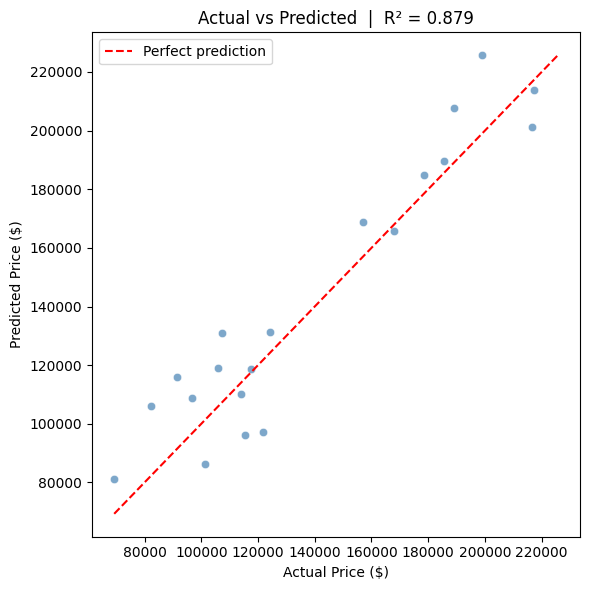

Actual vs Predicted plot saved.


In [17]:
# =============================================================
# STEP 11 — ACTUAL vs PREDICTED PLOT
# =============================================================
 
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
mn = min(y_test.min(), y_pred_test.min())
mx = max(y_test.max(), y_pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Actual vs Predicted  |  R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()
print("Actual vs Predicted plot saved.")

In [18]:
# =============================================================
# STEP 12 — MAKE A NEW PREDICTION (manual example)
# =============================================================
 
new_house = np.array([[1800, 3]])          # 1800 sq ft, 3 rooms
new_scaled = (new_house - mean) / std
new_b      = np.hstack([[1], new_scaled.flatten()])  # add bias
 
predicted_price = new_b @ w
print(f"\nPredicted price for 1800 sq ft, 3 rooms: ${predicted_price:,.0f}")
 


Predicted price for 1800 sq ft, 3 rooms: $132,846


In [19]:
# =============================================================
# SUMMARY — What each weight means
# Note: weights are in scaled space; rough unscaled interpretation:
# w[0] = bias (intercept)
# w[1] = effect of size   per 1 std dev (~{std[0]:.0f} sq ft)
# w[2] = effect of rooms  per 1 std dev (~{std[1]:.1f} rooms)
# =============================================================
 
print("\n--- Learned Weights (scaled space) ---")
print(f"  Bias  (w0): {w[0]:>10,.2f}")
print(f"  Size  (w1): {w[1]:>10,.2f}  (per {std[0]:.0f} sq ft)")
print(f"  Rooms (w2): {w[2]:>10,.2f}  (per {std[1]:.2f} rooms)")


--- Learned Weights (scaled space) ---
  Bias  (w0): 136,418.22
  Size  (w1):  44,885.84  (per 893 sq ft)
  Rooms (w2):  10,517.44  (per 1.39 rooms)
